---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04
date: 2025-04-06
authors:
  - name: Professor Craig Cahillane
    orcid: 0000-0002-3888-314X
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

This is the fourth homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, April 6th, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


In [2]:
%matplotlib widget
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
from ipywidgets import *

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        # "figure.autolayout": True,
        # "font.family": "serif",
        # "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

# Transmitted Field Dither Locking

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


## Plot of Fabry-Perot $E_\mathrm{trans}$ versus $E_\mathrm{trans}$

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?


## Total $E_\mathrm{trans}$ with end-mirror moduation 

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?


## Calculate the total transmitted power $P_\mathrm{trans}(t)$

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

## Calculate the transmitted power demodulated at $\omega$ 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

## Plot the length to transmitted power function phase sweep
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$

## Plot the length to transmitted power transfer function

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

# Dither Locking Solutions


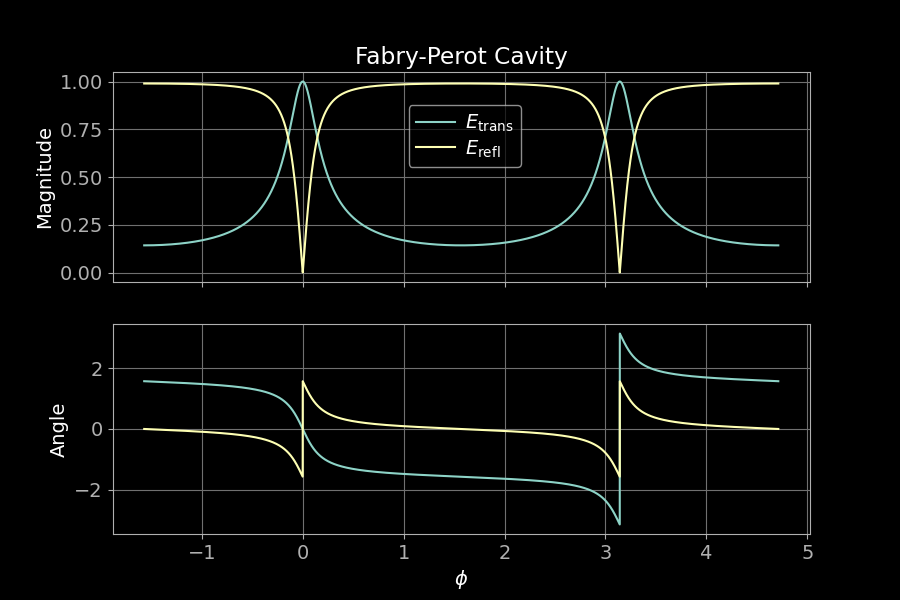

In [4]:
def Etrans(phis, r1, r2):
    t1 = np.sqrt(1-r1**2)
    t2 = np.sqrt(1-r2**2)
    return (t1 * t2 * np.exp(-1j * phis))/(1-r1*r2 * np.exp(-2j * phis))

def Erefl(phis, r1, r2):
    t1 = np.sqrt(1-r1**2)
    t2 = np.sqrt(1-r2**2)
    return (r1 - r2 * np.exp(-2j * phis))/(1-r1*r2 * np.exp(-2j * phis))

fig1, (ax11, ax12) = plt.subplots(2, sharex=True)

phis = np.linspace(-np.pi/2, 3 * np.pi/2, 10000)

r1 = np.sqrt(0.75)
r2 = np.sqrt(0.75)

plot_trans = np.angle(Etrans(phis, r1, r2))
plot_transm = np.abs(Etrans(phis, r1, r2))
plot_refl = np.angle(Erefl(phis, r1, r2))
plot_reflm = np.abs(Erefl(phis, r1, r2))
ax12.plot(phis, plot_trans)
ax12.plot(phis, plot_refl)
ax12.set_xlabel(r"$\phi$")
ax12.set_ylabel(r"Angle")
ax12.grid()
ax11.plot(phis, plot_transm,label=r"$E_\mathrm{trans}$")
ax11.plot(phis, plot_reflm,label=r"$E_\mathrm{refl}$")
ax11.set_ylabel(r"Magnitude")
ax11.set_title(r"Fabry-Perot Cavity")
ax11.grid()
ax11.legend(bbox_to_anchor=(0.6, 0.5))
plt.show()

<b> a) </b>

The minima and maxima occur at the same phase value, when  $E_\mathrm{trans}$ is at its maximum, $E_\mathrm{refl}$ is at a minima.

<b> b) </b>

$E_\mathrm{trans} = \dfrac{t_1 t_2 e^{-i\phi}}{1-r_1 r_2 e^{-2i\phi}}$

Using the transfer function:

$\dfrac{E_\mathrm{trans}}{E_\mathrm{cav2}} = -\dfrac{r_1 t_1 e^{-2i\phi}}{1-r_1 r_2 e^{-2i\phi}}$

I can then follow the steps from the in class assignment using Mathematica to get:

$E_\mathrm{trans} (t) = e^{i\omega_0 t}E_0\left( \dfrac{t_1 t_2 e^{-i\phi}}{1-r_1 r_2 e^{-2i\phi}} - \dfrac{i k \Delta x t_1 t_2 r_1 r_2 e^{-i(\phi+2(\eta+\phi)-\omega t)}}{(1-r_1 r_2 e^{-2i\phi})(1-r_1 r_2 e^{-2i(\eta+\phi)})} - \dfrac{i k \Delta x t_1 t_2 r_1 r_2 e^{-i(\phi+2(\eta+\phi)+\omega t)}}{(1-r_1 r_2 e^{-2i\phi})(1-r_1 r_2 e^{-2i(\eta+\phi)})} \right)$

Where the first term in the parentheses is the carrier, the second is the upper sideband, and the third is the lower sideband. And $\phi = \omega_0 L / c$ and $\eta = \omega L / c$

<b> c) </b>

From Mathematica:

$P_\mathrm{trans} (t) = E_0^2\left( \dfrac{t_1^2 t_2^2}{1-r_1^2 r_2^2 - 2r_1 r_2 \cos{(2\phi)}} - \dfrac{4 k r_1 r_2 t_1^2 t_2^2 \Delta x \cos{(\omega t)} \sin{(2(\eta+\phi))}}{(1+r_1^2 r_2^2 - 2r_1 r_2 \cos{(2\phi)})(1+r_1^2 r_2^2 - 2r_1 r_2 \cos{(2(\eta + \phi))})} \right)$

<b> d) </b>

From Mathematica:

$P_\mathrm{trans}^I (\omega) = -E_0^2 \Delta x \dfrac{2kr_1 r_2 t_1^2 t_2^2 \sin{(2(\eta+\phi))}}{(1+r_1^2 r_2^2 - 2r_1 r_2 \cos{(2\phi)})(1+r_1^2 r_2^2 - 2r_1 r_2 \cos{(2(\eta+\phi))})}$

$P_\mathrm{trans}^Q (\omega) = 0$




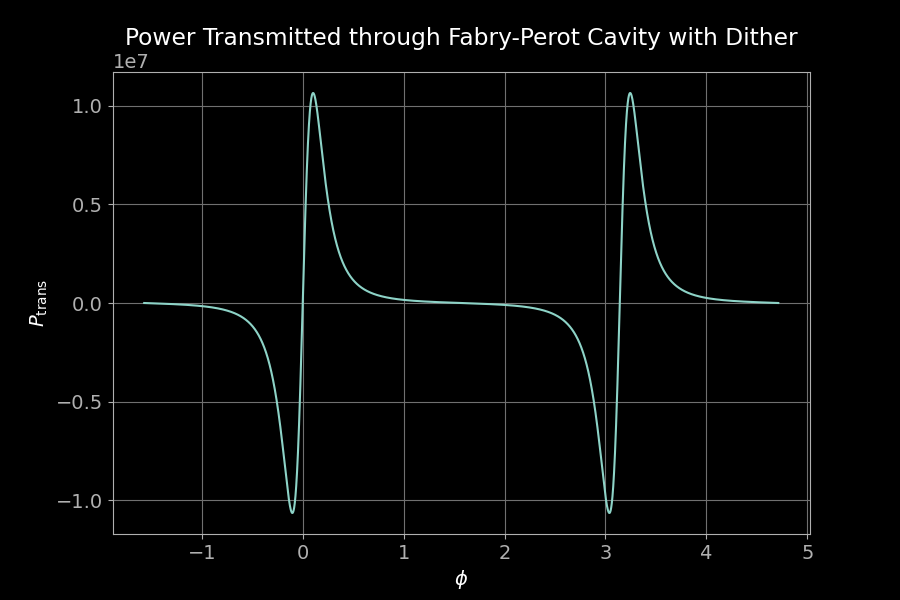

In [5]:
def Ptrans(phis, etas,T1, T2, k):
    t1 = np.sqrt(T1)
    t2 = np.sqrt(T2)
    r1 = np.sqrt(1-t1**2)
    r2 = np.sqrt(1-t2**2)
    return 2*k*r1*r2*(t1**2)*(t2**2)*np.sin(2*(etas+phis))/((1+r1**2 * r2**2 - 2*r1*r2*np.cos(2*phis))*(1+r1**2 * r2**2 - 2*r1*r2*np.cos(2*(etas+phis))))

omega = 2*np.pi*100
lam = 1064e-9
k = 2*np.pi/lam
c = 3e8
phis = np.linspace(-np.pi/2, 3 * np.pi/2, 10000)
etas = omega/c
T1 = 0.3
T2 = 0.3

plot_Ptrans = Ptrans(phis, etas, T1, T2, k)
fig2 = plt.figure()
plt.plot(phis, plot_Ptrans)
plt.xlabel(r"$\phi$")
plt.ylabel(r"$P_\mathrm{trans}$")
plt.title(r"Power Transmitted through Fabry-Perot Cavity with Dither")
plt.grid()
plt.show()

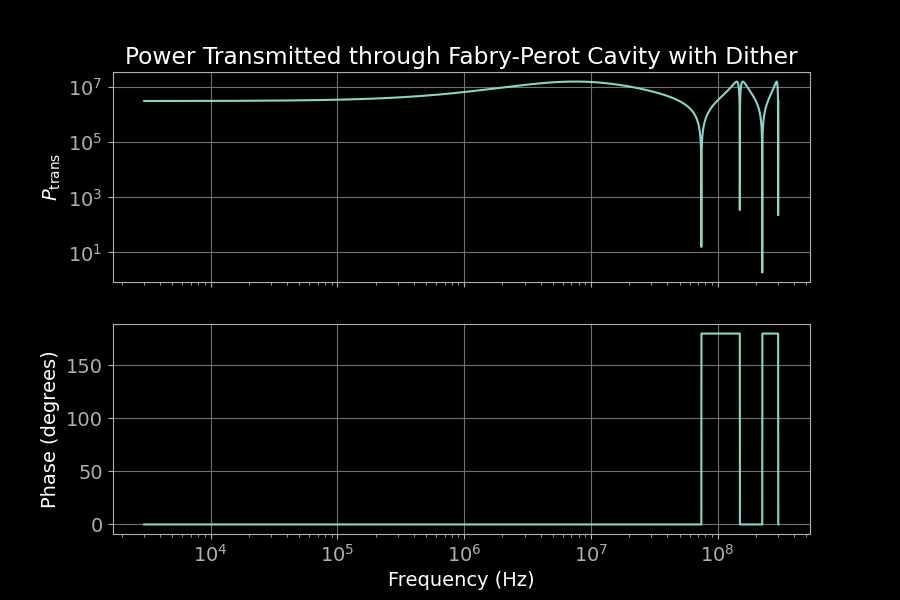

In [6]:
def Ptrans(phi, etas,T1, T2, k):
    t1 = np.sqrt(T1)
    t2 = np.sqrt(T2)
    r1 = np.sqrt(1-t1**2)
    r2 = np.sqrt(1-t2**2)
    return 2*k*r1*r2*(t1**2)*(t2**2)*np.sin(2*(etas+phi))/((1+r1**2 * r2**2 - 2*r1*r2*np.cos(2*phi))*(1+r1**2 * r2**2 - 2*r1*r2*np.cos(2*(etas+phi))))


f = np.linspace(3e3, 3e8, 1000000)
omega = 2*np.pi*f
lam = 1064e-9
k = 2*np.pi/lam
c = 3e8
phi = np.pi/180
etas = omega/c
T1 = 0.3
T2 = 0.3

plot_Ptrans2 = Ptrans(phi, etas, T1, T2, k)
fig3, (ax31, ax32) = plt.subplots(2, sharex=True)
ax31.loglog(f, np.abs(plot_Ptrans2))
ax32.semilogx(f, 180/np.pi*np.angle(plot_Ptrans2))
ax31.set_title(r"Power Transmitted through Fabry-Perot Cavity with Dither")
ax31.set_ylabel(r"$P_\mathrm{trans}$")
ax31.grid()
ax32.set_xlabel(r"Frequency (Hz)")
ax32.set_ylabel(r"Phase (degrees)")
ax32.grid()
plt.show()

# Pound-Drever-Hall Michelson

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.

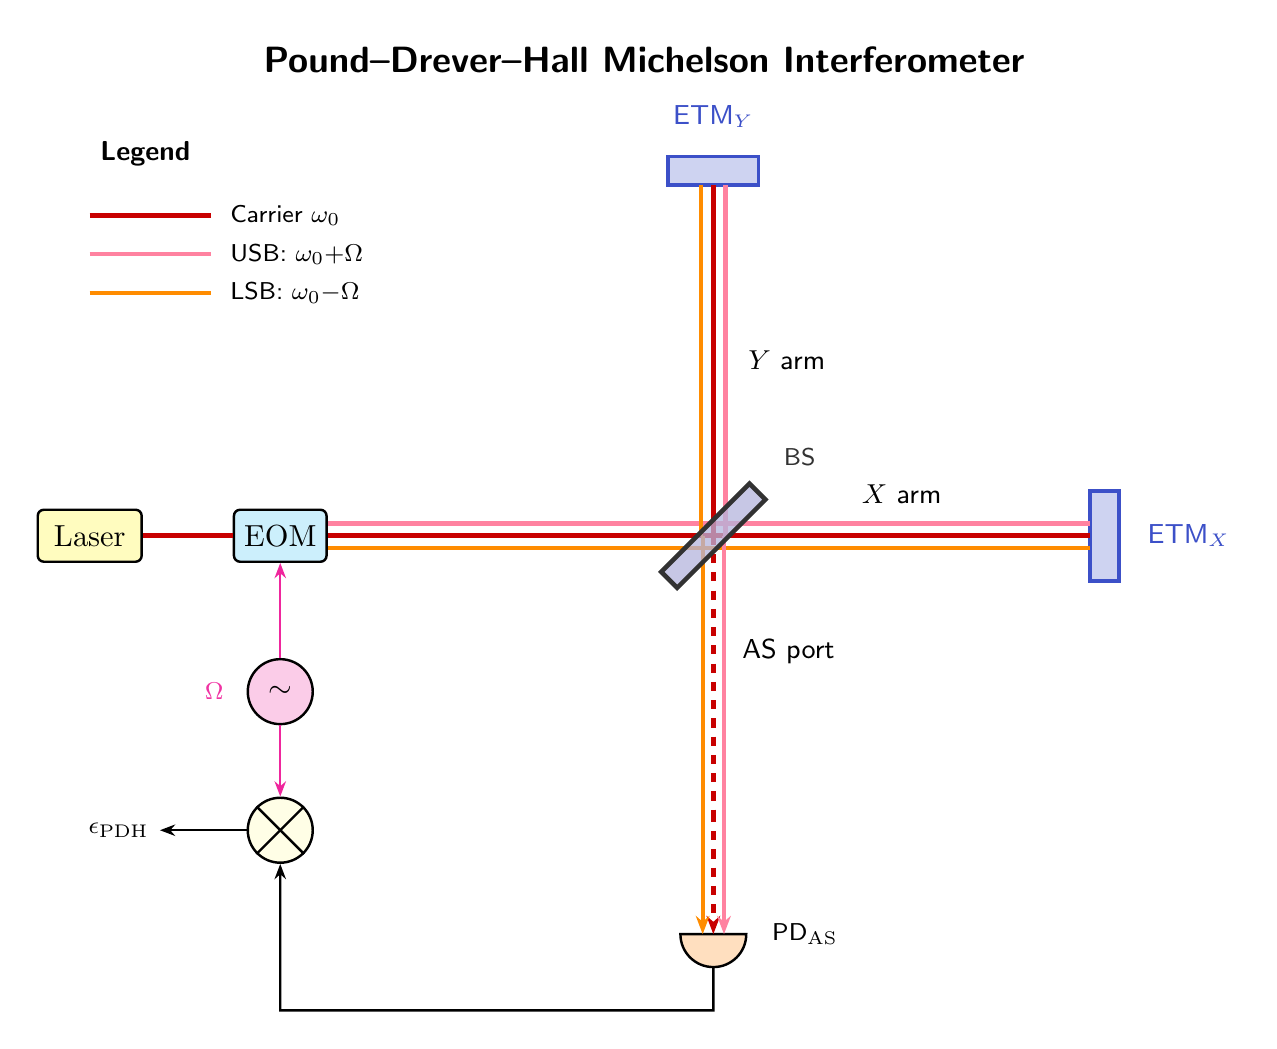

## Calculate the total dark field $E_{as}(t)$.

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

## Calculate the total dark power $P_{as}(t)$.

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.

## Calculate the dark power demodulated at $\Omega$ 

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?


# PDH Solutions:
<b> a) </b>

$E_\mathrm{in} (t) = E_0 e^{i\omega_0 t} \left( 1+i\dfrac{\Gamma}{2}e^{i \Omega t}+i\dfrac{\Gamma}{2}e^{-i\Omega t}\right)$

$E_\mathrm{as} = -ie^{-i\phi_c}\sin{(\phi_d)}E_\mathrm{in}$

$E_\mathrm{as} (t) = -ie^{-i\phi_c}E_0 \left( \sin{(\phi_d)}+i\sin{(\phi_d+\varphi_d)}\dfrac{\Gamma}{2}e^{i (\omega_0+\Omega) t}+i\sin{(\phi_d-\varphi_d)}\dfrac{\Gamma}{2}e^{i(\omega_0 - \Omega )t}\right)$

If $L_x = L_y$, $\phi_d = \varphi_d = 0$, and so $E_\mathrm{as} = 0$.

<b> b) </b>

Mathematica:

$P_\mathrm{as} (t) = \dfrac{1}{8} i e^{-i (2 \phi_d + \varphi_d)} (-1 + e^{4 i \phi_d}) (-1+ e^{2 i \varphi_d}) E_0^2 \Gamma$


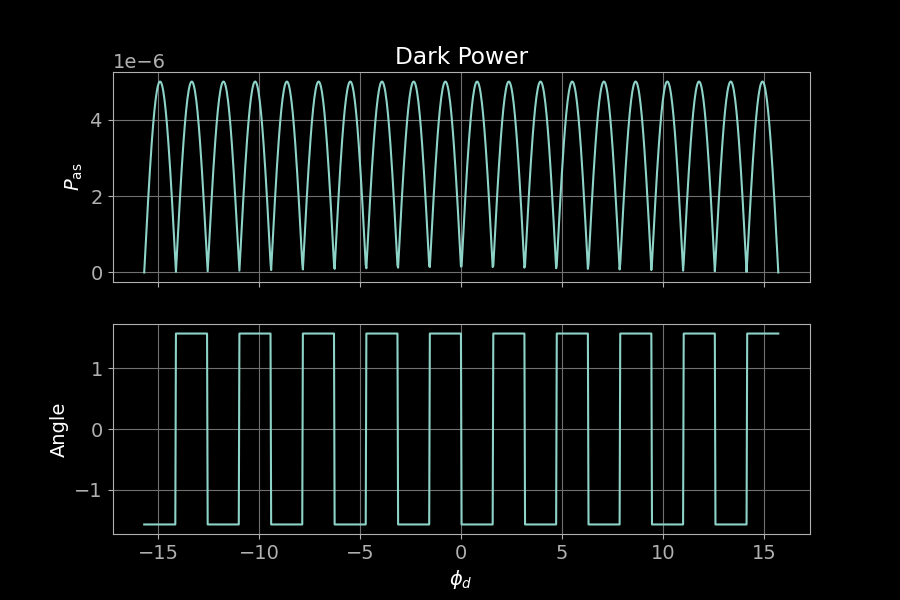

In [7]:
def P_as(phid, varphid):
    return 1/8 * 1j * np.exp(-1j*(2*phid+varphid))*(np.exp(4j*phid)-1)*(np.exp(2j*varphid)-1)


phid = np.linspace(-5*np.pi, 5*np.pi, 1000)
Omega = 2*np.pi*10e6
varphid = 0.00001

plot_Pas = P_as(phid, varphid)
fig4, (ax41, ax42) = plt.subplots(2, sharex=True)
ax41.plot(phid, np.abs(plot_Pas))
ax42.plot(phid, np.angle(plot_Pas))
ax41.set_title(r"Dark Power")
ax41.set_ylabel(r"$P_\mathrm{as}$")
ax41.grid()
ax42.set_xlabel(r"$\phi_d$")
ax42.set_ylabel(r"Angle")
ax42.grid()
plt.show()

If the arm lengths are exactly equal, the sidebands have no differential phase, so there is no beat signal. As the offset increases, the demodulated signal behaves sinusoidally, meaning that it is periodic, this means that as $\phi_d$ increases, the signal does not keep increasing. This also means that the PDH signal only will correct within a limited range around the dark fringe.

# Fabry-Perot Michelson Interferometer (FPMI)

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.

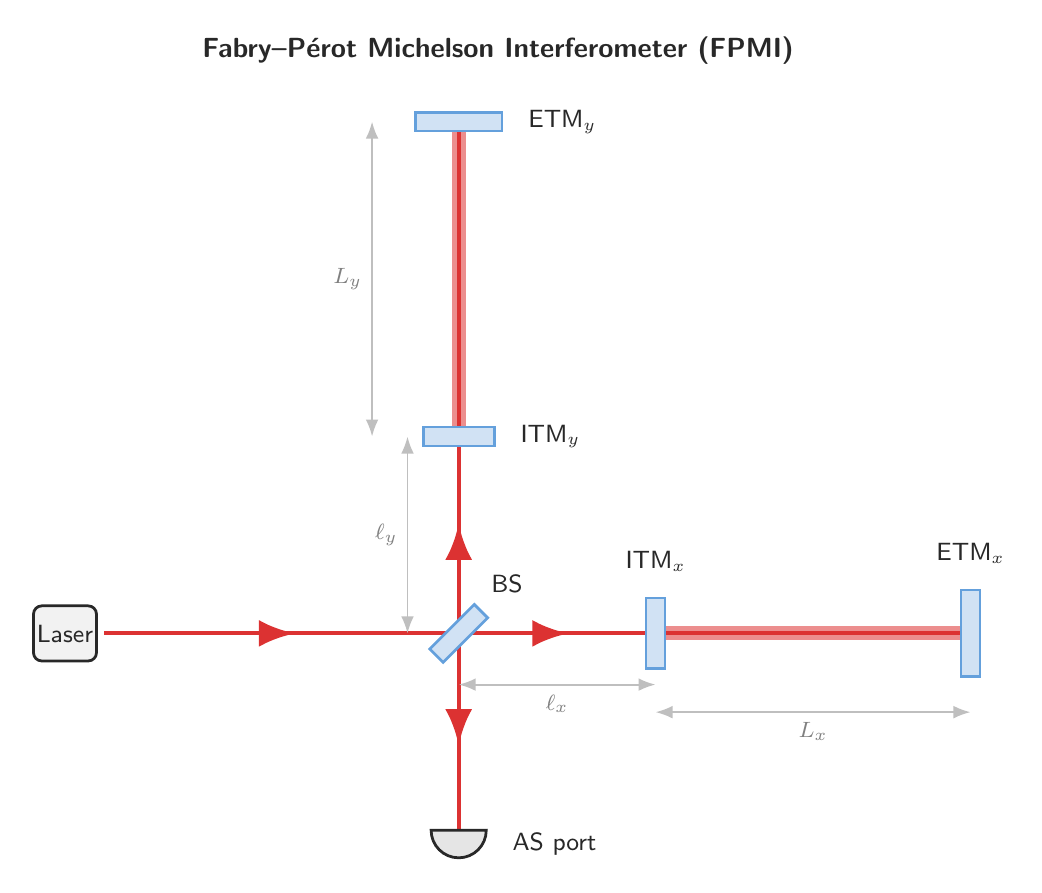

## Adjacency Matrix

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.

## Antisymmetric Port Field Derivations

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?

## Simplifications to $E_\mathrm{as}$

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.

## Interpretation

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}




# FPMI Solutions 
<b> a) </b>

$E_\mathrm{x1} = t_\mathrm{bs} e^{-i\phi_x}E_\mathrm{in}$

$E_\mathrm{cavx} = -r_\mathrm{itmx}e^{-i\Phi_x}E_\mathrm{cav2x} + t_\mathrm{itmx}E_\mathrm{x1}$

$E_\mathrm{cav2x} = -r_\mathrm{etmx} e^{-i\Phi_x}E_\mathrm{cavx}$

$E_\mathrm{x2} = t_\mathrm{itmx} e^{-i\Phi_x}e^{-i\phi_x}E_\mathrm{cav2x} + r_\mathrm{itmx}e^{-i\phi_x}E_\mathrm{x1}$

$E_\mathrm{y1} = r_\mathrm{bs} e^{-i\phi_y}E_\mathrm{in}$

$E_\mathrm{cavy} = -r_\mathrm{itmy}e^{-i\Phi_y}E_\mathrm{cav2y} + t_\mathrm{itmy}E_\mathrm{y1}$

$E_\mathrm{cav2y} = -r_\mathrm{etmy} e^{-i\Phi_y}E_\mathrm{cavx}$

$E_\mathrm{y2} = t_\mathrm{itmy} e^{-i\Phi_y}e^{-i\phi_y}E_\mathrm{cav2x} + r_\mathrm{itmy}e^{-i\phi_y}E_\mathrm{y1}$

$E_\mathrm{as} = -r_\mathrm{bs}E_\mathrm{x2} + t_\mathrm{bs}E_\mathrm{y2}$

$E_\mathrm{refl} = t_\mathrm{bs}E_\mathrm{x2} + r_\mathrm{bs}E_\mathrm{y2}$

$M = \left(
\begin{array}{ccccccccccc}
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 t_{\text{bs}} e^{-i \phi _x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & t_{\text{itmx}} & 0 & r_{\text{itmx}} \left(-e^{-i \Phi _x}\right) & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & r_{\text{etmx}} \left(-e^{-i \Phi _x}\right) & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & r_{\text{itmx}} e^{-i \phi _x} & 0 & t_{\text{itmx}} e^{-i \Phi _x-i \phi _x} & 0 & 0 & 0 & 0 & 0
   & 0 & 0 \\
 r_{\text{bs}} e^{-i \phi _y} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & t_{\text{itmy}} & 0 & r_{\text{itmy}} \left(-e^{-i \Phi _y}\right) & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 0 & r_{\text{etmy}} \left(-e^{-i \Phi _y}\right) & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & r_{\text{itmy}} e^{-i \phi _y} & 0 & t_{\text{itmy}} e^{-i \Phi _y-i \phi _y} & 0
   & 0 & 0 \\
 0 & 0 & 0 & 0 & -r_{\text{bs}} & 0 & 0 & 0 & t_{\text{bs}} & 0 & 0 \\
 0 & 0 & 0 & 0 & t_{\text{bs}} & 0 & 0 & 0 & r_{\text{bs}} & 0 & 0 \\
\end{array}
\right)$

<b> b) </b>


This creates an 11x11 matrix $M$ which can be put into Mathematica to get $(I-M)^{-1}$

$\displaystyle \frac{E_\mathrm{as}}{E_\mathrm{in}}=$

$\frac{-r_{\text{bs}} t_{\text{bs}} r_{\text{etmx}} r_{\text{etmy}} r_{\text{itmx}}^2 r_{\text{itmy}}
   e^{-2 i \Phi _x-2 i \phi _x-2 i \Phi _y}+r_{\text{bs}} t_{\text{bs}} r_{\text{etmx}} r_{\text{etmy}}
   r_{\text{itmx}} t_{\text{itmy}}^2 e^{-2 i \Phi _x-2 i \Phi _y-2 i \phi _y}+r_{\text{bs}}
   t_{\text{bs}} r_{\text{etmx}} r_{\text{etmy}} r_{\text{itmx}} r_{\text{itmy}}^2 e^{-2 i \Phi _x-2 i
   \Phi _y-2 i \phi _y}-r_{\text{bs}} t_{\text{bs}} r_{\text{etmx}} r_{\text{etmy}} t_{\text{itmx}}^2
   r_{\text{itmy}} e^{-2 i \Phi _x-2 i \phi _x-2 i \Phi _y}-r_{\text{bs}} t_{\text{bs}} r_{\text{etmx}}
   r_{\text{itmx}} r_{\text{itmy}} e^{-2 i \Phi _x-2 i \phi _y}+r_{\text{bs}} t_{\text{bs}}
   r_{\text{etmx}} r_{\text{itmx}}^2 e^{-2 i \Phi _x-2 i \phi _x}+r_{\text{bs}} t_{\text{bs}}
   r_{\text{etmx}} t_{\text{itmx}}^2 e^{-2 i \Phi _x-2 i \phi _x}+r_{\text{bs}} t_{\text{bs}}
   r_{\text{etmy}} r_{\text{itmx}} r_{\text{itmy}} e^{-2 i \phi _x-2 i \Phi _y}-r_{\text{bs}}
   t_{\text{bs}} r_{\text{etmy}} t_{\text{itmy}}^2 e^{-2 i \Phi _y-2 i \phi _y}-r_{\text{bs}}
   t_{\text{bs}} r_{\text{etmy}} r_{\text{itmy}}^2 e^{-2 i \Phi _y-2 i \phi _y}-r_{\text{bs}}
   t_{\text{bs}} r_{\text{itmx}} e^{-2 i \phi _x}+r_{\text{bs}} t_{\text{bs}} r_{\text{itmy}} e^{-2 i
   \phi _y}}{r_{\text{etmx}} r_{\text{etmy}} r_{\text{itmx}} r_{\text{itmy}} e^{-2 i \Phi _x-2 i \Phi
   _y}+r_{\text{etmx}} r_{\text{itmx}} \left(-e^{-2 i \Phi _x}\right)-r_{\text{etmy}} r_{\text{itmy}}
   e^{-2 i \Phi _y}+1}$

$\displaystyle \frac{E_\mathrm{refl}}{E_\mathrm{in}}=$

$\frac{r_{\text{bs}}^2 r_{\text{etmx}} r_{\text{etmy}} r_{\text{itmx}} t_{\text{itmy}}^2 e^{-2 i \Phi
   _x-2 i \Phi _y-2 i \phi _y}+t_{\text{bs}}^2 r_{\text{etmx}} r_{\text{etmy}} r_{\text{itmx}}^2
   r_{\text{itmy}} e^{-2 i \Phi _x-2 i \phi _x-2 i \Phi _y}+t_{\text{bs}}^2 r_{\text{etmx}}
   r_{\text{etmy}} t_{\text{itmx}}^2 r_{\text{itmy}} e^{-2 i \Phi _x-2 i \phi _x-2 i \Phi
   _y}+r_{\text{bs}}^2 r_{\text{etmx}} r_{\text{etmy}} r_{\text{itmx}} r_{\text{itmy}}^2 e^{-2 i \Phi
   _x-2 i \Phi _y-2 i \phi _y}-r_{\text{bs}}^2 r_{\text{etmx}} r_{\text{itmx}} r_{\text{itmy}} e^{-2 i
   \Phi _x-2 i \phi _y}-t_{\text{bs}}^2 r_{\text{etmx}} r_{\text{itmx}}^2 e^{-2 i \Phi _x-2 i \phi
   _x}-t_{\text{bs}}^2 r_{\text{etmx}} t_{\text{itmx}}^2 e^{-2 i \Phi _x-2 i \phi _x}-t_{\text{bs}}^2
   r_{\text{etmy}} r_{\text{itmx}} r_{\text{itmy}} e^{-2 i \phi _x-2 i \Phi _y}-r_{\text{bs}}^2
   r_{\text{etmy}} t_{\text{itmy}}^2 e^{-2 i \Phi _y-2 i \phi _y}+r_{\text{bs}}^2 r_{\text{etmy}}
   r_{\text{itmy}}^2 \left(-e^{-2 i \Phi _y-2 i \phi _y}\right)+t_{\text{bs}}^2 r_{\text{itmx}} e^{-2 i
   \phi _x}+r_{\text{bs}}^2 r_{\text{itmy}} e^{-2 i \phi _y}}{r_{\text{etmx}} r_{\text{etmy}}
   r_{\text{itmx}} r_{\text{itmy}} e^{-2 i \Phi _x-2 i \Phi _y}+r_{\text{etmx}} r_{\text{itmx}}
   \left(-e^{-2 i \Phi _x}\right)-r_{\text{etmy}} r_{\text{itmy}} e^{-2 i \Phi _y}+1}$

These are both very long equations but I assume the reflection equation does simplify down to $r_\mathrm{FP}(\Phi_x)$

<b> c) </b>

With the simplifications given:

$r_\mathrm{itmx} = r_\mathrm{itmy} = r_1$

$r_\mathrm{etmx} = r_\mathrm{etmy} = r_2$

$\displaystyle \frac{E_\mathrm{as}}{E_\mathrm{in}} = \frac{i \left(r_1^2-1\right) r_2 \sin \left(2 \Phi _d\right)}{-i \left(r_1^2
   r_2^2-1\right) \sin \left(2 \Phi _c\right)+\left(r_1^2 r_2^2+1\right) \cos \left(2
   \Phi _c\right)-2 r_1 r_2 \cos \left(2 \Phi _d\right)}$

<b> d) </b>

Looking at the plots, the FPMI definitely is more sensitive to changes in $\phi_d$ than a regular Michelson interferometer.



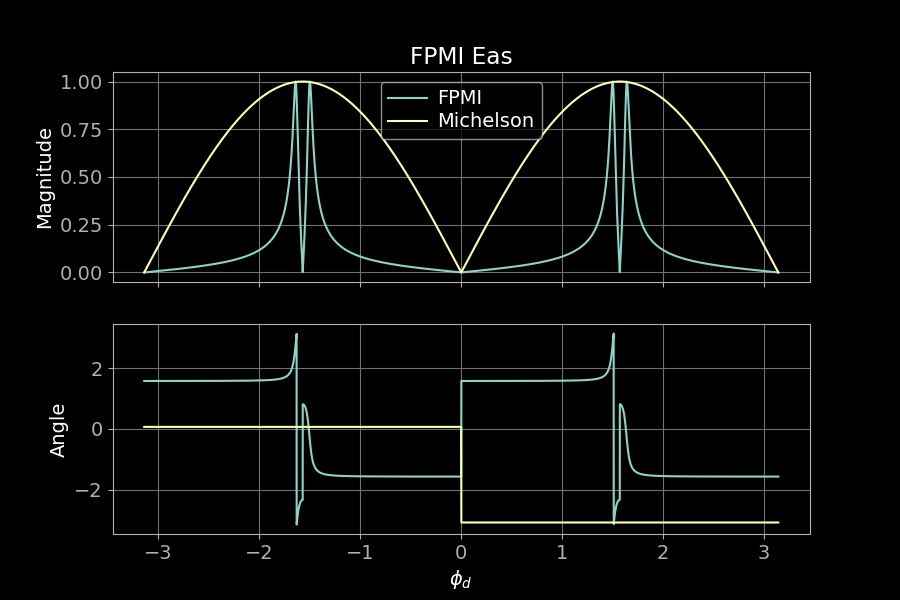

In [8]:
def Eas(phid, phic, T1,T2):
    r1 = np.sqrt(1-T1)
    r2 = np.sqrt(1-T2)
    return (1j*(r1**2-1)*r2*np.sin(2*phid))/(-1j*(r1**2 * r2**2 -1)*np.sin(2*phic)+(r1**2 * r2**2 + 1)*np.cos(2*phic)-2*r1*r2*np.cos(2*phid))

def EasMich(phid, phic, T1,T2):
    r1 = np.sqrt(1-T1)
    r2 = np.sqrt(1-T2)
    return -1j*np.exp(-1j*phic)*np.sin(phid)

phid = np.linspace(-np.pi, np.pi, 10000)
phic = 4000*2
T1 = 0.1
T2 = 0

plot_Eas = Eas(phid, phic, T1, T2)
plot_EasMich = EasMich(phid, phic, T1, T2)
fig5, (ax51, ax52) = plt.subplots(2, sharex=True)
ax51.plot(phid, np.abs(plot_Eas),label=r"FPMI")
ax51.plot(phid, np.abs(plot_EasMich),label=r"Michelson")
ax52.plot(phid, np.angle(plot_Eas))
ax52.plot(phid, np.angle(plot_EasMich))
ax51.set_title(r"FPMI Eas")
ax51.set_ylabel(r"Magnitude")
ax51.grid()
ax52.set_xlabel(r"$\phi_d$")
ax52.set_ylabel(r"Angle")
ax52.grid()
ax51.legend()
plt.show()